In [59]:
import pandas as pd
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split

# Part A: Understanding the Dataset 

### Q1. Dataset Overview
#### Load the dataset and answer the following:
####  How many rows and columns are present?
####  What are the names of all columns?
####  Display the first 10 records. 

In [10]:
df=pd.read_csv("agriculture_yield_dataset.csv")

In [ ]:
print(f"The no.of Rows and column are {df.shape[0]} and {df.shape[1]} resp.")
print("Column Names:", df.columns.tolist())
df.head(10)

The no.of Rows and column are 1500 and 8 resp.
The columns are Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='str')



,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


### Q2. Data Types and Missing Values
####  Check the data type of each column.
####  Identify whether any missing values are present.
####  If missing values exist, mention the affected columns.

In [19]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   rainfall_mm            1500 non-null   float64
 1   temperature_c          1500 non-null   float64
 2   fertilizer_kg          1500 non-null   float64
 3   irrigation_hours       1500 non-null   float64
 4   soil_ph                1500 non-null   float64
 5   crop_type              1500 non-null   str    
 6   soil_type              1500 non-null   str    
 7   yield_ton_per_hectare  1500 non-null   float64
dtypes: float64(6), str(2)
memory usage: 93.9 KB


rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

### Q3. Descriptive Statistics
#### Generate summary statistics for all numerical features and answer:
####  Which feature has the highest mean value?
####  Which feature has the highest standard deviation? 

In [22]:
df.describe()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,754.054667,27.749467,148.744067,5.403267,6.759133,5.028793
std,255.097216,5.758101,56.990279,2.584329,0.719742,0.968282
min,300.200000,18.000000,50.300000,1.000000,5.500000,2.090000
25%,536.175000,22.600000,98.600000,3.200000,6.100000,4.337500
50%,761.200000,27.700000,146.850000,5.400000,6.800000,5.010000
75%,964.375000,32.600000,196.575000,7.600000,7.400000,5.740000
max,1200.000000,38.000000,249.900000,10.000000,8.000000,7.860000


In [23]:
summary = df.describe()

# Highest mean
highest_mean_feature = summary.loc['mean'].idxmax()
highest_mean_value = summary.loc['mean'].max()

# Highest standard deviation
highest_std_feature = summary.loc['std'].idxmax()
highest_std_value = summary.loc['std'].max()

print("Highest Mean:", highest_mean_feature, highest_mean_value)
print("Highest Standard Deviation:", highest_std_feature, highest_std_value)

Highest Mean: rainfall_mm 754.0546666666667
Highest Standard Deviation: rainfall_mm 255.09721614450967


# Part B: Exploratory Data Analysis (EDA) 

In [24]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

### Q4. Distribution Analysis
#### Create histograms for:
####  rainfall_mm
####  temperature_c
####  fertilizer_kg
####  yield_ton_per_hectare
#### Write 2–3 observations from each histogram. 

In [ ]:
import plotly.express as px

# Rainfall
fig = px.histogram(
    df,
    x='rainfall_mm',
    nbins=20,
    title='Distribution of Rainfall'
)
fig.update_layout(bargap=0.2)
fig.show()

# Temperature
fig = px.histogram(
    df,
    x='temperature_c',
    nbins=20,
    title='Distribution of Temperature'
)
fig.update_layout(bargap=0.2)
fig.show()

# Fertilizer
fig = px.histogram(
    df,
    x='fertilizer_kg',
    nbins=20,
    title='Distribution of Fertilizer Usage'
)
fig.update_layout(bargap=0.2)
fig.show()

# Yield
fig = px.histogram(
    df,
    x='yield_ton_per_hectare',
    nbins=20,
    title='Distribution of Crop Yield'
)
fig.update_layout(bargap=0.2)
fig.show()

#####   ------------OBSERVATIONS--------------
#####  1) Rainfall (rainfall_mm)
#####  Most rainfall values are concentrated around the central range.
#####  The distribution shows moderate variability across observations.
#####  Extreme rainfall values occur less frequently.

#####  2) Temperature (temperature_c)
#####  Temperatures are spread across a reasonable range.
#####  Most observations lie near the average temperature.
#####  No major gaps are visible in the distribution.

#####  3) Fertilizer (fertilizer_kg)
#####  Fertilizer usage is concentrated around the middle values.
#####  The distribution appears relatively balanced.
#####  Very low and very high fertilizer usage levels are less common.

#####  4) Yield (yield_ton_per_hectare)
#####  Most crop yields are clustered around the mean yield.
#####  The frequency decreases as we move away from the center.
#####  The distribution suggests moderate variation in crop productivity.

### Q5. Crop Type Analysis
####  Find the number of records for each crop type.
####  Create a count plot (bar chart) for crop_type.
####  Which crop appears most frequently? 

In [27]:
crop_counts = df['crop_type'].value_counts()
print(crop_counts)

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


In [28]:
crop_counts = df['crop_type'].value_counts().reset_index()
crop_counts.columns = ['crop_type', 'count']

fig = px.bar(
    crop_counts,
    x='crop_type',
    y='count',
    title='Number of Records by Crop Type',
    labels={
        'crop_type': 'Crop Type',
        'count': 'Count'
    }
)

fig.show()

In [29]:
most_frequent_crop = df['crop_type'].value_counts().idxmax()
count = df['crop_type'].value_counts().max()

print(f"The most frequent crop is {most_frequent_crop} whose quantity is {count}")

The most frequent crop is Cotton whose quantity is 311


### Q6. Soil Type Analysis 
####  Find the frequency of each soil type.
####  Create a count plot for soil_type.
####  Which soil type is most common? 

In [31]:
soil_counts = df['soil_type'].value_counts()
print(soil_counts)

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


In [32]:
soil_counts = df['soil_type'].value_counts().reset_index()
soil_counts.columns = ['soil_type', 'count']

fig = px.bar(
    soil_counts,
    x='soil_type',
    y='count',
    title='Number of Records by Soil Type',
    labels={
        'soil_type': 'Soil Type',
        'count': 'Count'
    }
)

fig.show()

In [33]:
most_common_soil = df['soil_type'].value_counts().idxmax()
count = df['soil_type'].value_counts().max()

print("Most Common Soil Type:", most_common_soil)
print("Count:", count)

Most Common Soil Type: Clay
Count: 534


### Q7. Yield Distribution
#### Create a histogram of yield_ton_per_hectare.
#### Answer:
####  Is the distribution approximately normal?
####  Are there any noticeable outliers? 

In [36]:
fig = px.histogram(
    df,
    x='yield_ton_per_hectare',
    nbins=20,
    title='Distribution of Crop Yield',
    labels={'yield_ton_per_hectare':'Yield (ton/hectare)',
            'count': 'Frequency' }
)

fig.update_layout(bargap=0.2)
fig.show()

##### Is the distribution approximately normal?

##### Yes, approximately normal.
##### The histogram is bell-shaped, with a single peak around 5 tons/hectare.
##### Frequencies gradually increase toward the center and decrease toward both ends.
##### The distribution appears fairly symmetric, although there is a slight right skew.
##### Are there any noticeable outliers?

##### No significant outliers are visible.

##### Most yield values lie between 4 and 6.5 tons/hectare.
##### There are a few observations near 2–3 and 7–8 tons/hectare, but they are not isolated enough to be considered strong outliers.
##### The tails decrease smoothly rather than showing extreme standalone values.

### Q8. Scatter Plot Analysis
#### Create scatter plots of:
#### 1. rainfall_mm vs yield_ton_per_hectare
#### 2. fertilizer_kg vs yield_ton_per_hectare
#### Based on the plots:
####  Which feature appears to have a stronger relationship with yield? 

In [37]:
fig = px.scatter(
    df,
    x='rainfall_mm',
    y='yield_ton_per_hectare',
    title='Rainfall vs Crop Yield'
)

fig.update_xaxes(title='Rainfall (mm)')
fig.update_yaxes(title='Yield (ton/hectare)')

fig.show()

In [38]:
fig = px.scatter(
    df,
    x='fertilizer_kg',
    y='yield_ton_per_hectare',
    title='Fertilizer Usage vs Crop Yield'
)

fig.update_xaxes(title='Fertilizer (kg)')
fig.update_yaxes(title='Yield (ton/hectare)')

fig.show()

#### ✅ Rainfall_mm appears to have a stronger relationship with crop yield than fertilizer_kg, as its scatter plot exhibits a clearer upward trend and less variability around the trend.

### Q9. Correlation Analysis
####  Generate a correlation matrix for numerical features.
####  Create a heatmap.
####  Identify the top three features most correlated with crop yield. 

In [42]:
corr_matrix = df.corr(numeric_only=True)

print(corr_matrix)


                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

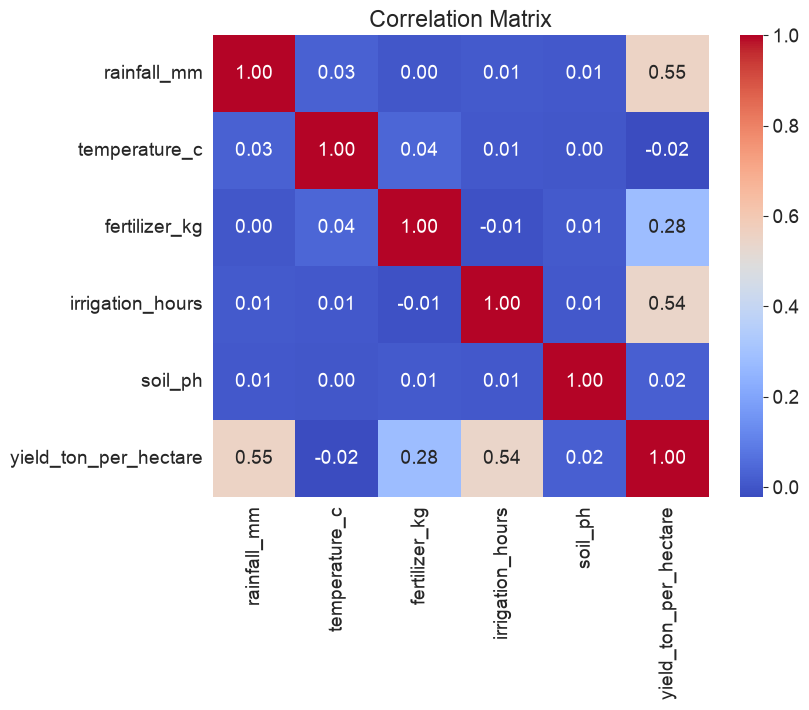

In [43]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

In [ ]:
corr_with_yield = corr_matrix['yield_ton_per_hectare'].sort_values(ascending=False)
print(corr_with_yield)

yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
soil_ph                  0.024412
temperature_c           -0.022559
Name: yield_ton_per_hectare, dtype: float64


### Q10. Group-Based Analysis
#### Calculate the average yield for:
####  Each crop type
####  Each soil type
#### Which crop and soil type have the highest average yield? 

In [ ]:
crop_avg_yield = df.groupby('crop_type')['yield_ton_per_hectare'].mean()
print(crop_avg_yield)
#groupby() is used when you want to split the data into groups and perform calculations on each group separately.

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64


In [48]:
soil_avg_yield = df.groupby('soil_type')['yield_ton_per_hectare'].mean()
print(soil_avg_yield)

soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64


In [49]:
highest_soil = soil_avg_yield.idxmax()
highest_soil_yield = soil_avg_yield.max()

print(highest_soil)
print(highest_soil_yield)

Loamy
5.366518987341772


## Part C: Data Preparation 

### Q11. Feature Encoding
#### The dataset contains categorical variables.
####  Identify the categorical columns.
####  Convert them into numerical form using One-Hot Encoding.
####  Display the first five rows of the transformed dataset. 

In [50]:
df.select_dtypes(include='object').columns

/var/folders/1m/1yxlv4zx6kj23d5y0h6jm1cc0000gn/T/ipykernel_81031/3732952691.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['crop_type', 'soil_type'], dtype='str')

In [ ]:
# One-Hot Encoding 
df_encoded = pd.get_dummies(
    df,
    columns=['crop_type', 'soil_type'],
    dtype=int
)

df_encoded.head()
#Label Encoding assigns a unique integer to each category, while 
#One-Hot Encoding creates separate binary (0/1) columns for each category, avoiding any artificial order between them.

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Cotton,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Clay,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,0,1,0,0,0,0,1,0
1,772.8,34.6,247.2,10.0,6.5,6.24,0,1,0,0,0,0,0,1
2,970.9,36.3,168.4,7.3,6.4,4.77,0,0,0,0,1,0,0,1
3,611.7,19.0,121.7,3.7,6.0,4.04,0,1,0,0,0,0,1,0
4,696.1,29.6,184.6,5.1,6.1,5.17,1,0,0,0,0,1,0,0


### Q12. Feature Selection 
#### Separate:
####  Input features (X)
####  Target variable (y)
#### Specify which column is being used as the target variable. 

In [56]:
X = df_encoded.drop('yield_ton_per_hectare', axis=1)

y = df_encoded['yield_ton_per_hectare']

##### The column yield_ton_per_hectare is used as the target variable because it represents the crop yield that the model aims to predict, while all remaining columns are used as input features.

## Part D: Machine Learning 

### Q13. Train-Test Split
#### Split the dataset into:
####  80% Training Data
####  20% Testing Data
#### Display the shape of:
####  X_train
####  X_test
####  y_train
####  y_test 

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.20,
                                                    random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1200, 13)
X_test shape: (300, 13)
y_train shape: (1200,)
y_test shape: (300,)


### Q14. Linear Regression Model
####  Train a Linear Regression model.
####  Display the model coefficients and intercept.
####  Which feature has the highest positive coefficient? 

In [63]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 0. ,-0.01, 0. ,..., 0.06, 0.37,-0.43]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['rainfall_mm','temperature_c','fertilizer_kg',...,'soil_type_Clay', 'soil_type_Loamy','soil_type_Sandy']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.911
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,11


In [64]:
print("Intercept:", model.intercept_)

print("\nCoefficients:")
for feature, coef in zip(X_train.columns, model.coef_):
    print(feature, ":", coef)

Intercept: 1.911102618280073

Coefficients:
rainfall_mm : 0.002035447987894068
temperature_c : -0.009174955414978108
fertilizer_kg : 0.004977992138483359
irrigation_hours : 0.19832728166589067
soil_ph : 0.004901189169335862
crop_type_Cotton : -0.38662342722296583
crop_type_Maize : -0.14769254885515337
crop_type_Rice : 0.4773694124782622
crop_type_Soybean : 0.09509596386187061
crop_type_Wheat : -0.03814940026201263
soil_type_Clay : 0.06265283667901574
soil_type_Loamy : 0.3656270466700266
soil_type_Sandy : -0.4282798833490424


In [65]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

highest_feature = coefficients.loc[
    coefficients['Coefficient'].idxmax()
]

print(highest_feature)

Feature        crop_type_Rice
Coefficient          0.477369
Name: 7, dtype: object
